In [17]:
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_community.embeddings import JinaEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END

from dotenv import load_dotenv
import re
from pydantic import BaseModel, Field
from typing import List, TypedDict, Any, Optional

In [2]:
docs = (
    PyPDFLoader('../documents/ENISA Report - Securing Machine Learning Algorithms.pdf').load() +
    PyPDFLoader("../documents/Securing the machine learning lifecycle.pdf").load()
)

chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

load_dotenv('../configs/.env')
embeddings = JinaEmbeddings(model_name="jina-embeddings-v3")
db = FAISS.from_documents(chunks, embeddings)
retriever = db.as_retriever(search_kwargs={"k": 3, "task": "retrieval.query"})

In [3]:
load_dotenv('../configs/.env')

# PROD AUDIT SETTINGS (Maximum Precision)
llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    temperature=0.0,  # Zero randomness
    top_p=0.1,        # Only consider top 10% of logical possibilities
    model_kwargs={"thinking_level": "high"} # Gemini 3 specific
)

UPPER_TH = 0.7
LOWER_TH = 0.3

c:\Users\Fawad\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\interactiveshell.py:3699: UserWarning: Parameters {'thinking_level'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [30]:
class State(TypedDict):
    question: str
    docs: List[Document]
    good_docs: List[Document]
    recommend_fix_only: bool
    verdict: str
    reason: str
    strips: List[str]
    kept_strips: List[str]
    refined_context: str
    web_queries: List[str]
    web_docs: List[Document]
    fix_recommendations: set[str]
    vulnerable_code: str
    entire_fixed_code: str
    fixed_code_cost_reduced: str
    final_report: Any
    display_report: str

In [5]:
# retriever
def retrieval_node(state: State) -> State:
    q = state['question']
    return {'docs': retriever.invoke(q)}

In [6]:
# Documents evaluation Schema
class DocEvaluator(BaseModel):
    """Score the relevance of a retrieved security document."""
    score: float = Field(description="Relevance score: 1.0 (Critical security context), 0.5 (General context), 0.0 (Irrelevant)")
    is_relevant: bool = Field(description="Binary decision: True if score > 0.5")
    reason: str = Field(description="Brief explanation of why this document helps or hinders a security audit.")

# Evaluation Prompt
evaluation_prompt = ChatPromptTemplate.from_messages([
    (
        "system", 
        "You are the Lead Security ML Auditor. Your mission is to filter retrieved documents "
        "to ensure only high-fidelity technical security guidance (ENISA, NIST, OWASP) reaches the final agent.\n\n"
        "RELEVANCE CRITERIA:\n"
        "- 1.0: Contains specific threat vectors, mitigation steps, or code-level vulnerabilities.\n"
        "- 0.5: Discusses ML generalities but lacks actionable security insights.\n"
        "- 0.0: Marketing fluff, unrelated technical docs, or broken text."
    ),
    (
        "human", 
        "### TASK: EVALUATE RETRIEVAL QUALITY\n"
        "<user_query>\n{question}\n</user_query>\n\n"
        "<retrieved_document>\n{page_content}\n</retrieved_document>\n\n"
        "Based on the query and document above, provide the score and reasoning in structured JSON."
    )
])

doc_eval_chain = evaluation_prompt | llm.with_structured_output(DocEvaluator)

def eval_each_doc_node(state: State) -> State:
    q = state['question']
    scores : List[float] = []
    good_docs : List[Document] = []
    
    for doc in state['docs']:
        result = doc_eval_chain.invoke({
            "question": q,
            "page_content": doc.page_content
        })
        scores.append(result.score)
        if result.is_relevant and result.score > LOWER_TH:
            good_docs.append(doc)

    # CORRECT: at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good_docs,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # INCORRECT: all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}.",
        }

    # AMBIGUOUS: otherwise
    return {
        "good_docs": good_docs,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}.",
    }

In [7]:
import spacy, os

try:
    nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer", "textcat"])
    print("Loaded spaCy model successfully.")
except OSError:
    os.system("python -m spacy download en_core_web_sm")
    print("Downloaded and loaded spaCy model successfully.")
    nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer", "textcat"])

class SentenceSelection(BaseModel):
    """The list of sentence indices that are technically relevant."""
    relevant_indices: List[int] = Field(description="Indices of sentences to keep.")


sentences_eval_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an extrememly strict ML Security Document Refiner. " 
        "I will provide a list of numbered sentences. "
        "Select ONLY the indices of sentences that contain technical security facts, "
        "mitigation steps, or vulnerability evidence. Avoid fluff."
    ),
    (
        "human",
        "QUESTION: {question}\n\n"
        "SENTENCES:\n{indexed_sentences}\n\n"
        "Return the JSON list of relevant_indices."
    )
])

sentences_eval_chain = sentences_eval_prompt | llm.with_structured_output(SentenceSelection)

def decompose_to_sentences(text: str) -> List[str]:
    """Uses spaCy's statistical model to handle technical abbreviations correctly."""
    # Clean whitespace first
    text = re.sub(r"\s+", " ", text).strip()
    
    # Process text through spaCy
    doc = nlp(text)
    
    # Filter out very short noise (less than 20 chars)
    return [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 20]

def refine(state: State) -> State:
    """
    Refines context by filtering out 'noisy' sentences using batch LLM processing.
    """
    query = state["question"]
    verdict = state.get("verdict")

    # Routing logic based on CRAG verdict
    if verdict == "CORRECT":
        docs_to_use = state["good_docs"]
    elif verdict == "INCORRECT":
        docs_to_use = state["web_docs"]
    else:  # AMBIGUOUS
        docs_to_use = state.get("good_docs", []) + state.get("web_docs", [])

    # Full text extraction and decomposition
    raw_context = "\n\n".join(d.page_content for d in docs_to_use).strip()
    strips = decompose_to_sentences(raw_context)
    indexed_sentences = "\n".join(f"{i}: {s}" for i, s in enumerate(strips))

    try:
        # One request, one response.
        result = sentences_eval_chain.invoke({
            "question": query, 
            "indexed_sentences": indexed_sentences
        })
        kept_strips = [strips[i] for i in result.relevant_indices if i < len(strips)]
    except Exception as e:
        print(f"Refinement failed: {e}")
        kept_strips = strips[:5] # Fallback

    return {
        "kept_strips": kept_strips,
        "strips": strips,
        "refined_context": " ".join(kept_strips).strip(),
    }

Loaded spaCy model successfully.


In [31]:
import asyncio

# -----------------------------------------------------------
# 1. WEB QUERY REWRITER (Input: question -> Output: queries)
# -----------------------------------------------------------
class WebQuery(BaseModel):
    queries: List[str] = Field(description="3 distinct technical search queries.")

rewrite_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are the Sentinel-ML Query Optimizer. The internal security database failed to provide "
        "sufficient evidence for an audit. Your goal is to generate high-precision technical queries.\n\n"
        "RULES:\n"
        "- Use technical jargon (e.g., 'RCE', 'Zero-day', 'Hardening', 'Sanitization').\n"
        "- If a specific library or CVE is mentioned, include it.\n"
        "- Target high-authority sources implicitly (e.g., add 'site:github.com' or 'documentation' for one query).\n"
        "- For recency, use specific years (e.g., '2025' or '2026') rather than just 'latest'."
    ),
    (
        "human",
        "CONTEXT: The internal audit for the following question was incomplete.\n"
        "USER QUESTION: {question}\n\n"
        "Generate 3 optimized search queries in JSON format."
    ),
])
rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

def rewrite_query_node(state: State) -> dict:
    # Sirf queries generate karega
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_queries": out.queries}

# -----------------------------------------------------------
# 2. WEB SEARCH NODE (Input: web_queries -> Output: web_docs)
# -----------------------------------------------------------
load_dotenv('../configs/.env')
tavily = TavilySearchResults(max_results=2, search_depth="advanced")

def web_search_node(state: State) -> dict:
    queries = state.get("web_queries", [state["question"]])
    
    web_docs = []
    # We loop through queries one by one instead of parallel gathering
    for q in queries:
        search_results = tavily.invoke({"query": q})
        for r in search_results:
            doc = Document(page_content=f"SOURCE: {r['url']}\nCONTENT: {r['content']}")
            web_docs.append(doc)
            
    return {"web_docs": web_docs}
# ---------------------------------------------------------
# 3. FINAL RESOLVER (The "Brains" of the Operation)
# ---------------------------------------------------------
class AuditReport(BaseModel):
    summary: str
    vulnerability_details: str
    mitigation_steps: str
    confidence_score: float

resolver_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are the Sentinel-ML Final Resolver. Your task is to synthesize Internal Reports and Web Data "
        "into a single, concrete security audit report.\n\n"
        "CONFLICT RESOLUTION RULES:\n"
        "1. If Internal Docs and Web Data disagree on a NEW library version, trust the WEB.\n"
        "2. If they disagree on a SECURITY PRINCIPLE, trust the INTERNAL DOCS (ENISA/NIST).\n"
        "3. Explicitly mention if a conflict was found and why you chose one source over the other.\n"
        "4. Output must be technical, professional, and actionable."
    ),
    (
        "human",
        "USER QUESTION: {question}\n\n"
        "INTERNAL EVIDENCE:\n{refined_internal_context}\n\n"
        "WEB EVIDENCE:\n{web_context}\n\n"
        "Synthesize the final audit report in JSON format."
    ),
])
resolver_chain = resolver_prompt | llm.with_structured_output(AuditReport)

def generate_report_node(state: State) -> dict:
    # Sub data ko consolidate karna
    internal_text = state.get("refined_context", "None")
    web_text = "\n\n".join([d.page_content for d in state.get("web_docs", [])])
    
    report = resolver_chain.invoke({
        "question": state["question"],
        "refined_internal_context": internal_text,
        "web_context": web_text
    })
    
    # UI k liye Markdown formatted summary
    md = f"## Audit Summary\n{report.summary}\n\n### Fixes\n{report.mitigation_steps}"
    
    return {
        "final_report": report,
        "display_report": md,
        "refined_context": internal_text + "\n\n" + web_text.strip()
    }

In [32]:
# -----------------------------
# ML security auditor and fixer
# -----------------------------

class FixedSecurity(BaseModel):
    """Schema for the final output of the security audit, including threat level and code fixes."""
    threat_level: str = Field(description="Overall threat level: LOW, MEDIUM, HIGH, CRITICAL")
    fix_recommendations: set[str] = Field(description="Concise recommendations as code for fixing the identified issues.")
    entire_fixed_code: Optional[str] = Field(description="The complete, fixed code snippet that addresses the security vulnerabilities.")
    fixed_code_cost_reduced: Optional[str] = Field(description="A simplified version of the fixed code that reduces computational cost while maintaining security.")

fixing_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "SYSTEM ROLE: Lead AI Security Architect & Forensic Auditor.\n"
        "OBJECTIVE: Perform a high-fidelity security remediation of ML source code using the provided technical intelligence.\n\n"
        "REMEDIATION PROTOCOL:\n"
        "1. VULNERABILITY TAXONOMY: Map identified flaws to OWASP ML Top 10 (e.g., ML01: Input Layer Attack) and CWE identifiers.\n"
        "2. RISK ASSESSMENT: Assign 'threat_level' based on the CVSS v3.1 qualitative severity scale (Low, Medium, High, Critical).\n"
        "3. HARDENING STRATEGY (entire_fixed_code):\n"
        "   - Implement 'Defense in Depth'.\n"
        "   - Prioritize input sanitization, safe deserialization (avoiding pickle/yaml.load), and boundary checks.\n"
        "   - Ensure the code follows 'Secure-by-Design' principles, minimizing the attack surface.\n"
        "4. COMPUTATIONAL OPTIMIZATION (fixed_code_cost_reduced):\n"
        "   - Refactor hardened logic to minimize Big-O complexity.\n"
        "   - Use vectorized operations (NumPy/Tensor) to offset the latency overhead introduced by security checks.\n"
        "   - Maintain the same security entropy as the 'entire_fixed_code'.\n\n"
        "CONSTRAINTS:\n"
        "- If 'recommend_fix_only' is active, strictly provide technical rationales; omit code blocks.\n"
        "- No conversational filler. Output must be valid JSON."
    ),
    (
        "human",
        "### AUDIT INPUTS\n"
        "REFINED CONTEXT (Threat Intel): {refined_context}\n"
        "VULNERABLE SOURCE: {vulnerable_code}\n"
        "MODE_FLAG (recommend_fix_only): {recommend_fix_only}\n\n"
        "### EXECUTION\n"
        "Generate the structured audit and remediation report."
    )
])
fixing_chain = fixing_prompt | llm.with_structured_output(FixedSecurity)

def security_audit_node(state: State) -> dict:
    """
    Executes the high-fidelity remediation protocol.
    Integrates threat intel with vulnerable source code to produce hardened outputs.
    """

    # 1. Extract inputs from State
    # We ensure defaults exist to prevent the LLM from hallucinating missing data
    inputs = {
        "refined_context": state.get("refined_context", "No context provided."),
        "vulnerable_code": state.get("vulnerable_code", "# No code provided."),
        "recommend_fix_only": state.get("recommend_fix_only", False)
    }

    try:
        # 2. Invoke the Lead Architect Persona
        # Gemini 3 Flash will follow the CVSS and OWASP protocols defined in your prompt
        audit_result = fixing_chain.invoke(inputs)

        # 3. State Update Logic
        # We handle the 'None' cases for code blocks gracefully if recommend_fix_only was True
        return {
            "threat_level": audit_result.threat_level,
            "fix_recommendations": set(audit_result.fix_recommendations), # Storing as set for uniqueness
            "entire_fixed_code": audit_result.entire_fixed_code or "REDACTED: Text-only mode active.",
            "fixed_code_cost_reduced": audit_result.fixed_code_cost_reduced or "REDACTED: Text-only mode active.",
            "verdict": audit_result.threat_level, # Mapping threat level to verdict for routing
        }

    except Exception as e:
        # Robust error handling for production stability
        print(f"!!! [Audit Node Error]: {str(e)}")
        return {
            "verdict": "ERROR",
            "fix_recommendations": {"Error encountered during forensic audit."},
            "entire_fixed_code": f"Fail-safe triggered. Error: {str(e)}"
        }

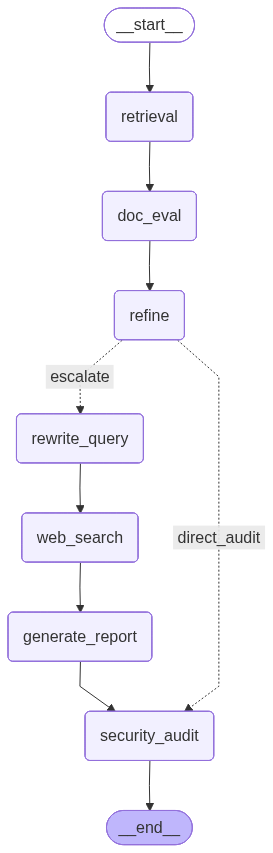

In [33]:
# -----------------------------------------------------------
# Workflow Crafting: The Surgical Sentinel-ML Path
# -----------------------------------------------------------

# 1. Initialize the Graph
workflow = StateGraph(State)

# 2. Add all Nodes from your script
workflow.add_node("retrieval", retrieval_node)
workflow.add_node("doc_eval", eval_each_doc_node)
workflow.add_node("refine", refine)
workflow.add_node("rewrite_query", rewrite_query_node)
workflow.add_node("web_search", web_search_node)
workflow.add_node("generate_report", generate_report_node)
workflow.add_node("security_audit", security_audit_node)

# 3. Define the Logic (The Edges)

# Step 1: Start with internal retrieval
workflow.set_entry_point("retrieval")

# Step 2: Evaluate what we found
workflow.add_edge("retrieval", "doc_eval")

# Step 3: Refine the initial internal docs
workflow.add_edge("doc_eval", "refine")

# Step 4: The Router (Based on your logic)
def decide_path(state: State):
    verdict = state.get("verdict")
    if verdict in ["INCORRECT", "AMBIGUOUS"]:
        return "escalate"
    return "direct_audit"

workflow.add_conditional_edges(
    "refine",
    decide_path,
    {
        "escalate": "rewrite_query", # Path for INCORRECT/AMBIGUOUS
        "direct_audit": "security_audit" # Path for CORRECT
    }
)

# Step 5: The Escalation Path (Web + Reporting)
workflow.add_edge("rewrite_query", "web_search")
workflow.add_edge("web_search", "generate_report")
workflow.add_edge("generate_report", "security_audit")

# Step 6: Final Termination
workflow.add_edge("security_audit", END)

# 4. Compile
app = workflow.compile()
app

In [ ]:
res = app.invoke({
    "question": "Find vulnerabilities in this model loading script and provide a secure, high-performance alternative.",
    "vulnerable_code": """import pickle
    import pandas as pd
    def load_user_model(user_id):
        # DANGEROUS: Loading model from untrusted user path
        path = f"models/{user_id}_model.pkl"
        with open(path, 'rb') as f:
            model = pickle.load(f) # <--- Potential RCE Vulnerability
        return model
    """,
    "query": "Find vulnerabilities in this model loading script and provide a secure, high-performance alternative.",
    "web_docs": [],
    "fixed_code_cost_reduced": "",
    "entire_fixed_code": "",
    "final_report": None,
    "display_report": "",
    "docs": [],
    "good_docs": [],
    "kept_strips": [],
    "strips": [],
    "refined_context": "",
    "recommend_fix_only": False,
    "verdict": " ",
    "reason": " ",
    "web_queries": [],
    "fix_recommendations": set()
})

print("Fixed code with reduced computational cost:\n", res['fixed_code_cost_reduced'])

Fixed code with reduced computational cost:
 from pathlib import Path
from safetensors.torch import load_file

def load_user_model(user_id):
    # Optimized safe loading: uses zero-copy memory mapping via safetensors
    # Minimalist path sanitization to reduce overhead
    safe_id = Path(user_id).name
    path = Path("models") / f"{safe_id}_model.safetensors"
    
    # load_file is significantly faster than pickle and inherently safe
    return load_file(str(path))


In [ ]:
# Free-tier exhausted -gonna run it after I get some more credits. The above 
# code is the complete implementation of the ML security agent with the specified
# nodes and workflow. You can run it in your environment once you have the necessary
# API access and dependencies set up.

# vulnerable_ml_snippet = """
# import pickle
# import base64

# def load_malicious_model(user_input_data):
#     # This simulates a model being sent over a network
#     raw_data = base64.b64decode(user_input_data)
#     model = pickle.loads(raw_data) # <--- CRITICAL VULNERABILITY
#     return model
# """
# query = "Identify the RCE risk in this model loading logic and rewrite it using a secure-by-design approach."

# final_state = app.invoke({
#     "question": query,
#     "vulnerable_code": vulnerable_ml_snippet,
#     "web_docs": [],
#     "fixed_code_cost_reduced": "",
#     "entire_fixed_code": "",
#     "final_report": None,
#     "display_report": "",
#     "docs": [],
#     "good_docs": [],
#     "kept_strips": [],
#     "strips": [],
#     "refined_context": "",
#     "recommend_fix_only": False,
#     "verdict": " ",
#     "reason": " ",
#     "web_queries": [],
#     "fix_recommendations": set()
# })

# print(f"VERDICT: {final_state['verdict']}")
# print(f"FIXED CODE:\n{final_state['entire_fixed_code']}")